In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

In [3]:
df = pd.read_csv('../data/raw/Prices.csv')
df.head()

,Date,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,PG,XOM
0,2015-01-02,24.237549,15.4260,26.278944,76.955551,46.511124,77.905800,39.858452,0.483011,66.518349,57.916889
1,2015-01-05,23.554735,15.1095,25.778227,76.418083,45.067196,76.654541,39.491920,0.474853,66.202065,56.332203
2,2015-01-06,23.556952,14.7645,25.142035,76.042580,43.898651,75.621750,38.912289,0.460457,65.900513,56.032726
3,2015-01-07,23.887281,14.9210,25.068092,77.721291,43.965630,75.621750,39.406689,0.459257,66.246216,56.600468
4,2015-01-08,24.805077,15.0230,25.155436,78.332405,44.948116,77.637688,40.565952,0.476533,67.003761,57.542580


In [4]:
X = df.drop(columns=['Date'])

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dimensionality Reduction

In this section, various dimensionality reduction techniques are applied to identify patterns and visualize high-dimensional data in lower dimensions.

PCA (Principal Component Analysis)

PCA is used to reduce the dimensionality of the dataset by transforming the original variables into principal components that capture the most variance in the data.

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

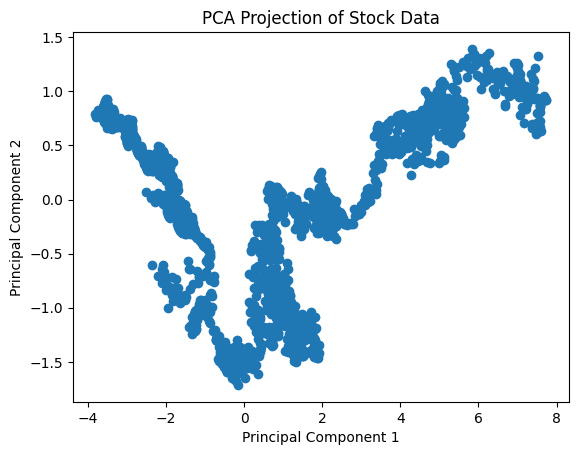

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA Projection of Stock Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

PCA Interpretation:
The PCA projection shows that the data follows a continuous, curved structure rather than forming clearly separated clusters. The points are distributed along a nonlinear path, indicating that the stock price data evolves gradually over time.

There is no strong separation into distinct groups, suggesting that the stocks exhibit correlated behavior rather than independent clustering. PCA captures the overall variance in the dataset, but because it is a linear method, it does not fully capture the nonlinear structure present in the data.

Overall, PCA provides a general overview of the data distribution but does not clearly distinguish separate patterns or clusters.

ICA (Independent Component Analysis)

Independent Component Analysis is used to separate independent signals in the data and identify underlying structure.

In [8]:
from sklearn.decomposition import FastICA

ica = FastICA(n_components=2, random_state=0)
X_ica = ica.fit_transform(X_scaled)

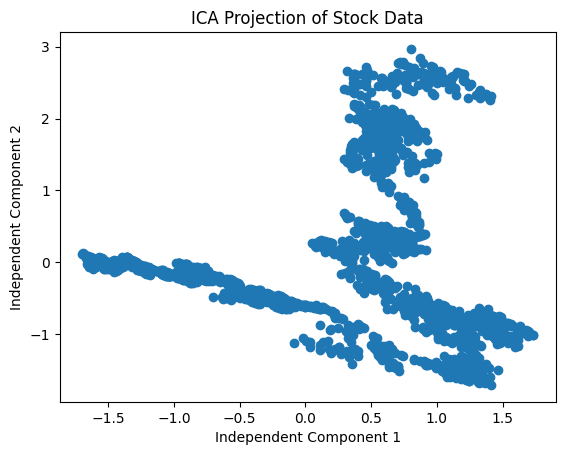

In [17]:
from sklearn.decomposition import FastICA

ica = FastICA(n_components=2, random_state=0)
X_ica = ica.fit_transform(X_scaled)

plt.scatter(X_ica[:, 0], X_ica[:, 1])
plt.title("ICA Projection of Stock Data")
plt.xlabel("Independent Component 1")
plt.ylabel("Independent Component 2")
plt.show()

ICA Interpretation:
The ICA projection reveals more distinct groupings in the data compared to PCA. While PCA showed a smooth, continuous structure, ICA separates the data into more segmented clusters and linear bands.

This suggests that ICA is able to identify more independent patterns within the stock data. However, the separation is still not completely distinct, indicating that while some independent behavior exists, the overall relationships between stock prices remain interconnected.

Overall, ICA provides slightly improved structural separation compared to PCA, but does not fully isolate clear clusters.

t-SNE (t-Distributed Stochastic Neighbor Embedding)

t-SNE is a nonlinear dimensionality reduction technique that focuses on preserving local structure and revealing clusters in high-dimensional data.

In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X_scaled)

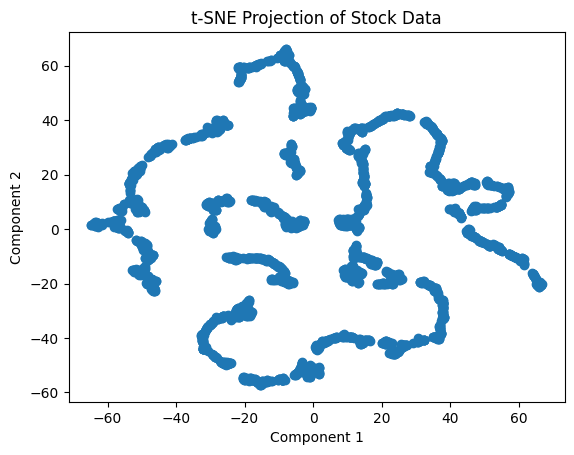

In [11]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
plt.title("t-SNE Projection of Stock Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

t-SNE Interpretation:
The t-SNE projection reveals significantly clearer separation between data points compared to PCA and ICA. The data forms multiple distinct clusters and localized groupings, indicating the presence of nonlinear relationships within the stock price data.

Unlike PCA and ICA, which produced more continuous and overlapping structures, t-SNE effectively captures local similarities and separates the data into more well-defined regions. This suggests that the underlying structure of the dataset is complex and nonlinear, making t-SNE a more effective method for visualizing patterns in this case.

Overall, t-SNE provides the clearest representation of clustering behavior among the dimensionality reduction methods tested so far.

Kernel PCA:
Kernel PCA extends standard PCA by applying a kernel function to capture nonlinear relationships in the data.

In [12]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kpca.fit_transform(X_scaled)

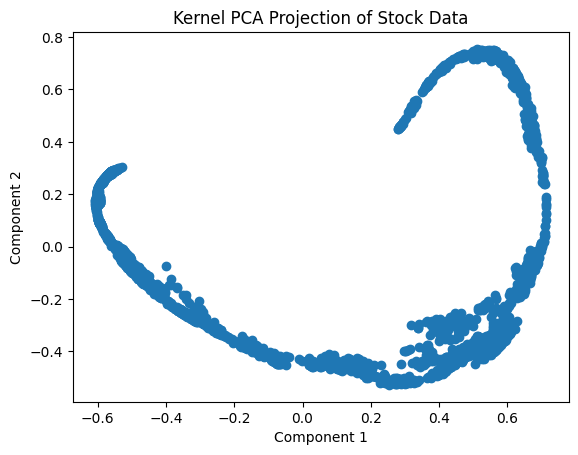

In [19]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kpca.fit_transform(X_scaled)

plt.scatter(X_kpca[:, 0], X_kpca[:, 1])
plt.title("Kernel PCA Projection of Stock Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

Kernel PCA Interpretation:
The Kernel PCA projection captures the nonlinear structure of the dataset more effectively than standard PCA. The data forms a smooth, curved shape with some separation into distinct regions, indicating that nonlinear relationships exist between the stock variables.

Compared to PCA, which produced a more compressed and continuous curve, Kernel PCA spreads the data out more clearly and highlights underlying structure. However, the data still does not form fully distinct clusters, suggesting that while nonlinear transformations improve representation, the dataset remains interconnected.

Overall, Kernel PCA provides a better representation of the data than PCA, but it does not achieve the level of separation observed with t-SNE.

Truncated SVD:

Truncated SVD is a dimensionality reduction technique similar to PCA that decomposes the data into components while preserving important structure.

In [20]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=0)
X_svd = svd.fit_transform(X_scaled)

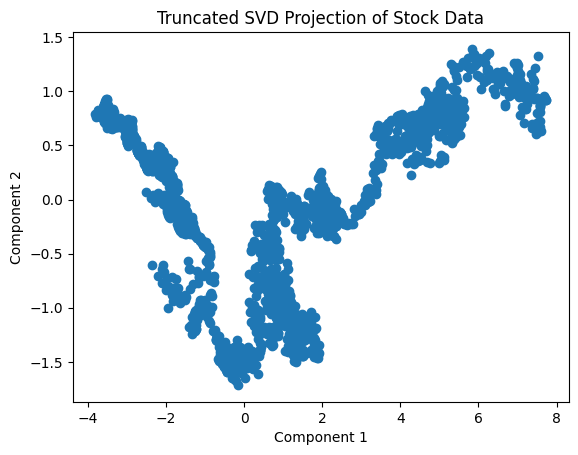

In [21]:
plt.scatter(X_svd[:, 0], X_svd[:, 1])
plt.title("Truncated SVD Projection of Stock Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

Truncated SVD Interpretation:
The Truncated SVD projection produces a distribution very similar to the PCA results, with the data forming a continuous, curved structure rather than distinct clusters. This indicates that the dominant patterns in the stock data are captured by both methods in a similar way.

The data shows gradual transitions rather than clear separations, suggesting that the stock variables are highly correlated and evolve together over time. Like PCA, Truncated SVD is a linear method and therefore does not fully capture the nonlinear relationships present in the dataset.

Overall, Truncated SVD provides a comparable representation to PCA, reinforcing that linear dimensionality reduction techniques are limited in their ability to reveal distinct groupings in this dataset.

Comparison of Dimensionality Reduction Methods:
PCA and Truncated SVD produced similar results, both showing a continuous, curved structure with no clear separation between groups. ICA provided slightly more segmentation but still did not clearly isolate clusters.

Kernel PCA improved upon PCA by capturing nonlinear structure, showing better separation between regions. However, t-SNE provided the clearest visualization of the data, revealing distinct clusters and highlighting nonlinear relationships more effectively than the other methods.

Overall, nonlinear methods such as Kernel PCA and t-SNE performed better than linear methods in representing the structure of the dataset.

KMeans Clustering:
KMeans clustering groups data into a specified number of clusters by minimizing the distance between points and cluster centers.

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels_kmeans = kmeans.fit_predict(X_pca)

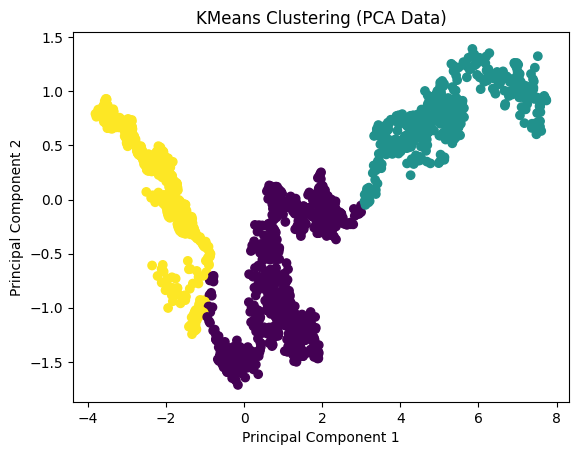

In [23]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans)
plt.title("KMeans Clustering (PCA Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

KMeans Interpretation:
The KMeans clustering algorithm divides the data into three distinct groups, which generally follow the overall curved structure observed in the PCA projection. The clusters are separated primarily along the horizontal direction, indicating that the first principal component plays a significant role in distinguishing the groups.

However, the clusters do not perfectly align with the natural shape of the data. The curved structure is split into segments rather than being grouped based on true underlying patterns. This occurs because KMeans assumes spherical clusters and relies on distance to cluster centers, which limits its ability to capture nonlinear relationships.

Overall, while KMeans identifies broad groupings within the dataset, it does not fully represent the inherent structure of the data, suggesting that more flexible clustering methods may provide better results.

Agglomerative (Hierarchical) Clustering:
Agglomerative clustering is a hierarchical method that builds clusters by iteratively merging the closest pairs of data points or clusters.

In [24]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_pca)

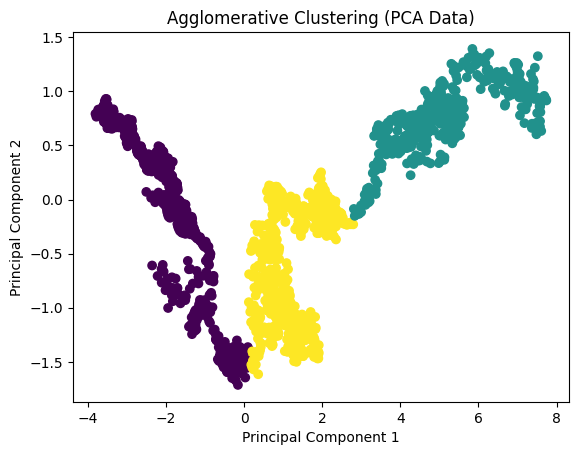

In [25]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg)
plt.title("Agglomerative Clustering (PCA Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Agglomerative Clustering Interpretation:
The Agglomerative clustering method groups the data into three clusters that follow the general curved structure observed in the PCA projection. The clusters appear as contiguous segments along the data distribution, indicating that the method is grouping nearby points based on their similarity.

Because Agglomerative clustering builds clusters by progressively merging neighboring points, it produces groupings that reflect the continuity of the dataset rather than forcing perfectly spherical clusters. However, the clusters are still somewhat broad and overlap in transitional regions, suggesting that the data does not have sharply defined boundaries.

Overall, Agglomerative clustering captures the general structure of the dataset, but the results indicate that the data is more continuous than distinctly separated into clear groups.

DBSCAN Clustering:
DBSCAN is a density-based clustering method that groups points based on regions of high density and identifies sparse regions as noise.

In [26]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_pca)

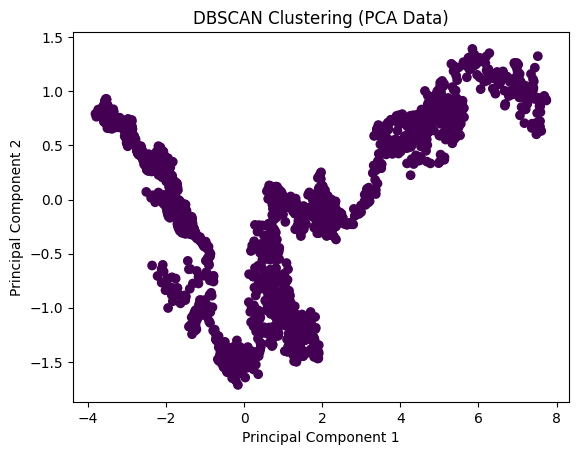

In [27]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db)
plt.title("DBSCAN Clustering (PCA Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Number of clusters found: 19


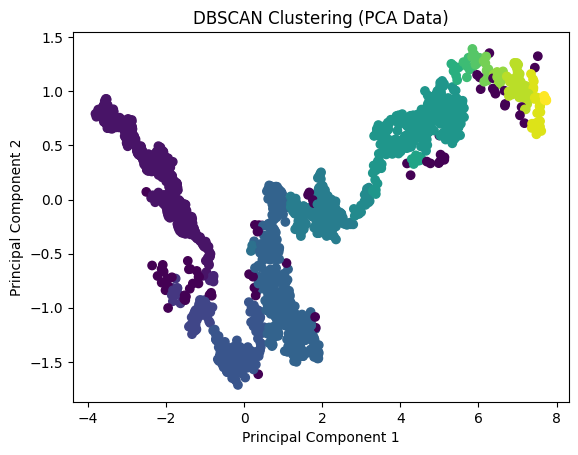

In [33]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# Apply DBSCAN (tuned eps for better separation)
dbscan = DBSCAN(eps=0.10, min_samples=5)
labels_db = dbscan.fit_predict(X_pca)

# Check how many clusters were found (excluding noise)
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print("Number of clusters found:", n_clusters)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db)
plt.title("DBSCAN Clustering (PCA Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

DBSCAN Interpretation:
DBSCAN identifies several smaller clusters that follow the curved structure of the data, rather than forcing it into a fixed number of groups. The clusters appear in localized regions, with some scattered points classified as noise.

This indicates that the dataset contains variations in density, and DBSCAN is able to capture these patterns more effectively than methods that assume uniform cluster shapes.

Comparison of Clustering Methods:
KMeans and Agglomerative clustering both divide the data into three broad groups, producing similar segmentations along the overall trend. While their approaches differ, the results suggest the dataset lacks strongly separated natural clusters.

In contrast, DBSCAN identifies clusters based on density and does not require a predefined number of groups. It captures smaller, localized patterns along the curved structure and identifies some noise points.

Overall, KMeans and Agglomerative provide simple, similar groupings, while DBSCAN offers a more flexible representation that better reflects the underlying structure of the data.

Real-World Clustering Interpretation:
The clusters observed in the data likely represent groups of stocks that exhibit similar behavior over time. Stocks within the same cluster may respond similarly to market conditions, indicating shared trends in price movement or volatility.

For example, clusters may group together stocks from similar sectors or with similar growth patterns, while separation between clusters suggests differences in how these stocks react to broader market dynamics.